In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import ast
from sklearn.metrics import accuracy_score
import copy
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score,average_precision_score)
from sklearn.neural_network import MLPClassifier

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
from scipy.stats import spearmanr
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

# Load

In [15]:
newness = np.load("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\newness_2024.npy",allow_pickle=True)
surprise = np.load("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\surprise_2024.npy",allow_pickle=True)
value = np.load("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\value_2024.npy",allow_pickle=True)

In [16]:
BASELINE_YEAR=1600

In [18]:
gold_set_70 = pd.read_excel("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Codes\\Evaluation\\golden_set_move_creative_70.xlsx")

In [20]:
creative_70 = np.load("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\creativity_70_full_prob.npy",allow_pickle=True)

In [21]:
artnet_2024 = pd.read_excel("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\ArtNet\\Artnet_Europe_2024_merged.xlsx")

In [22]:
merged_df = pd.merge(gold_set_70, artnet_2024[["artwork id","artist id","year born","workyear modifier","price","artist",'est lo usd','est hi usd', 'sale price usd']], on='artwork id', how='left')

In [23]:
merged_df.shape

(1874, 33)

In [24]:
newness_df = np.zeros(merged_df.shape[0], dtype=object)
surprise_df = np.zeros(merged_df.shape[0], dtype=object)
value_df = np.zeros(merged_df.shape[0], dtype=object)
for i in range(merged_df.shape[0]):
    row_index = merged_df.index[i]
    newness_df[i] =newness[row_index]
    surprise_df[i] =surprise[row_index]
    value_df[i] = value[row_index]

# Correlation

In [13]:
new_vs_surprise, pval = spearmanr(newness,surprise)
print(f"The Correlation between newness and Surprise is {new_vs_surprise}")

The Correlation between newness and Surprise is 0.2985509641365827


In [14]:
new_vs_value, pval = spearmanr(newness,value)
print(f"The Correlation between newness and value is {new_vs_value}")

The Correlation between newness and value is 0.042086096035055594


In [15]:
value_vs_surprise, pval = spearmanr(value,surprise)
print(f"The Correlation between surprise and value is {value_vs_surprise}")

The Correlation between surprise and value is 0.030809796371711884


# Cut off 0.85

## Basic
Balanced + Normalized (max min)

In [22]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [23]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [24]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [25]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [26]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


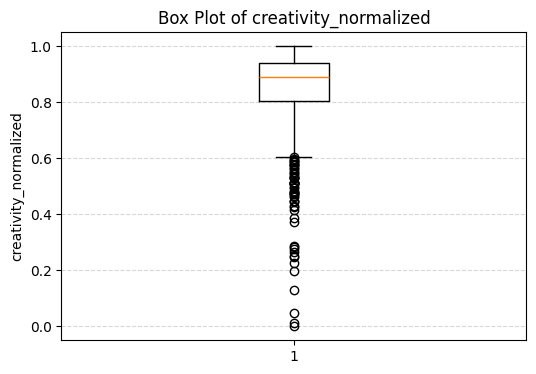

In [27]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [28]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [29]:
np.sum(y)/len(y)

np.float64(0.6346863468634686)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [31]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000, random_state=0)

In [32]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 50.23%
Test AUC: 0.5136672170243993
Test Precision: 0.6271186440677966
Test Recall: 0.5362318840579711
Test F1: 0.578125


In [33]:
confusion_matrix(y_test, model.predict(X_test))

array([[35, 44],
       [64, 74]])

## Splines 
Splines + Balanced + Normalized (max min)

In [34]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [35]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


In [36]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [37]:
np.sum(y)/len(y)

np.float64(0.6346863468634686)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [39]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [40]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [41]:
model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('spline',
                                                  SplineTransformer(extrapolation='linear',
                                                                    include_bias=False,
                                                                    n_knots=8),
                                                  [1, 2])])),
                ('logisticregressioncv',
                 LogisticRegressionCV(class_weight='balanced', cv=5,
                                      max_iter=5000, n_jobs=-1))])

In [42]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [43]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 53.00%
Test AUC: 0.5744817464685379
Test Precision: 0.6730769230769231
Test Recall: 0.5072463768115942
Test F1: 0.5785123966942148


In [44]:
confusion_matrix(y_test, y_pred)

array([[45, 34],
       [68, 70]])

## Neural Network

In [630]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [631]:
constant = np.ones(len(surprise_df))

In [632]:
y = [1 if i>=0.85 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [633]:
np.sum(y)/len(y)

np.float64(0.6346863468634686)

In [634]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [679]:
model = MLPClassifier(solver='lbfgs', alpha=4e-6,
                    hidden_layer_sizes=(16, 16), random_state=1,max_iter=5000)
model.fit(X_train, y_train)

MLPClassifier(alpha=4e-06, hidden_layer_sizes=(16, 16), max_iter=5000,
              random_state=1, solver='lbfgs')

In [680]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [681]:
# Training
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 59.45%
Test AUC: 0.5173362685745735
Test Precision: 0.6436781609195402
Test Recall: 0.8115942028985508
Test F1: 0.717948717948718


In [682]:
confusion_matrix(y_test, y_pred)

array([[ 17,  62],
       [ 26, 112]])

# Cut off 0.80

## Basic
Balanced + Normalized (max min)

In [45]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [46]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [47]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [48]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [49]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


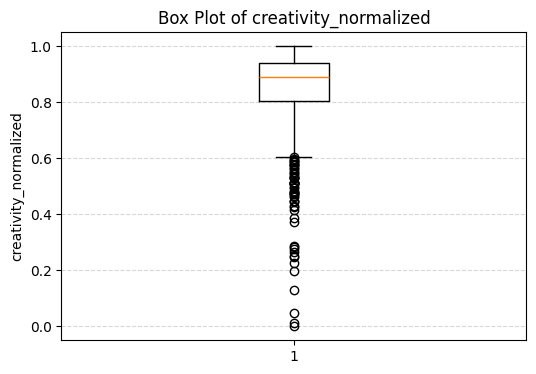

In [50]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [51]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [52]:
np.sum(y)/len(y)

np.float64(0.7555350553505535)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [54]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=10000, random_state=0)

In [55]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 54.84%
Test AUC: 0.6028531983433042
Test Precision: 0.8235294117647058
Test Recall: 0.5121951219512195
Test F1: 0.631578947368421


In [56]:
confusion_matrix(y_test, model.predict(X_test))

array([[35, 18],
       [80, 84]])

## Splines 
Splines + Balanced + Normalized (max min)

In [57]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [58]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


In [59]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [60]:
np.sum(y)/len(y)

np.float64(0.7555350553505535)

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [62]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [63]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [64]:
model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('spline',
                                                  SplineTransformer(extrapolation='linear',
                                                                    include_bias=False,
                                                                    n_knots=8),
                                                  [1, 2])])),
                ('logisticregressioncv',
                 LogisticRegressionCV(class_weight='balanced', cv=5,
                                      max_iter=5000, n_jobs=-1))])

In [65]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [66]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 56.68%
Test AUC: 0.5908881730326737
Test Precision: 0.8125
Test Recall: 0.5548780487804879
Test F1: 0.6594202898550725


In [44]:
confusion_matrix(y_test, y_pred)

array([[45, 34],
       [68, 70]])

## Neural Network

In [436]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [437]:
constant = np.ones(len(surprise_df))

In [438]:
y = [1 if i>=0.8 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [439]:
np.sum(y)/len(y)

np.float64(0.7555350553505535)

In [614]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [615]:
model = MLPClassifier(solver='lbfgs', alpha=5e-6,
                    hidden_layer_sizes=(16, 32), random_state=1,max_iter=5000)
model.fit(X_train, y_train)

MLPClassifier(alpha=5e-06, hidden_layer_sizes=(16, 32), max_iter=5000,
              random_state=1, solver='lbfgs')

In [616]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [617]:
# Training
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 73.27%
Test AUC: 0.5470547630004602
Test Precision: 0.7548076923076923
Test Recall: 0.9573170731707317
Test F1: 0.8440860215053764


In [618]:
confusion_matrix(y_test, y_pred)

array([[  2,  51],
       [  7, 157]])

# Cut off 0.60

## Basic
Balanced + Normalized (max min)

In [11]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [12]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [13]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [14]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [15]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


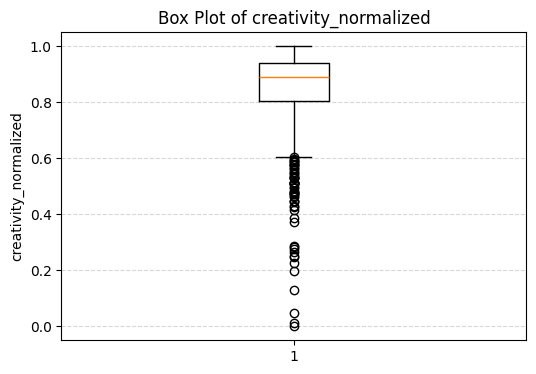

In [16]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [17]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [18]:
np.sum(y)/len(y)

np.float64(0.9474169741697417)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [20]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [21]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 52.53%
Test AUC: 0.4655781112091792
Test Precision: 0.9478260869565217
Test Recall: 0.529126213592233
Test F1: 0.6791277258566978


In [22]:
confusion_matrix(y_test, model.predict(X_test))

array([[  5,   6],
       [ 97, 109]])

## Splines 
Splines + Balanced + Normalized (max min)

In [23]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [24]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


In [25]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [26]:
np.sum(y)/len(y)

np.float64(0.9474169741697417)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [28]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [29]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [30]:
model.fit(X_train, y_train)

C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [31]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [32]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 53.46%
Test AUC: 0.5375110326566638
Test Precision: 0.9487179487179487
Test Recall: 0.5388349514563107
Test F1: 0.6873065015479877


In [33]:
confusion_matrix(y_test, y_pred)

array([[  5,   6],
       [ 95, 111]])

## Neural Network

In [34]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [35]:
constant = np.ones(len(surprise_df))

In [36]:
y = [1 if i>=0.6 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [37]:
np.sum(y)/len(y)

np.float64(0.9474169741697417)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [39]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [43]:
result=[]
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_train, y_train, sample_weight = sample_weights)
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:,1]
        acc = accuracy_score(y_test,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_test, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_test,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_test, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_test, y_pred)
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_test, y_pred)})
        #print("Test F1:", f1)


In [45]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",52.995392,0.481906,0.948276,0.533981,0.683230,"[[5, 6], [96, 110]]"
1,0.000001,"(4, 8)",57.603687,0.472639,0.945312,0.587379,0.724551,"[[4, 7], [85, 121]]"
2,0.000001,"(8, 8)",18.894009,0.459400,0.916667,0.160194,0.272727,"[[8, 3], [173, 33]]"
3,0.000001,"(8, 16)",46.543779,0.491174,0.950000,0.461165,0.620915,"[[6, 5], [111, 95]]"
4,0.000001,"(16, 16)",58.525346,0.518094,0.946154,0.597087,0.732143,"[[4, 7], [83, 123]]"
5,0.000001,"(16, 32)",61.751152,0.527802,0.948905,0.631068,0.758017,"[[4, 7], [76, 130]]"
6,0.000003,"(4, 4)",17.972350,0.475728,0.937500,0.145631,0.252101,"[[9, 2], [176, 30]]"
7,0.000003,"(4, 8)",58.064516,0.456311,0.945736,0.592233,0.728358,"[[4, 7], [84, 122]]"
8,0.000003,"(8, 8)",60.368664,0.572816,0.954545,0.611650,0.745562,"[[5, 6], [80, 126]]"
9,0.000003,"(8, 16)",47.465438,0.484113,0.950980,0.470874,0.629870,"[[6, 5], [109, 97]]"


# Cut off 0.5

## Basic
Balanced + Normalized (max min)

In [46]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)

In [47]:
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)

In [48]:
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)

In [49]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [50]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


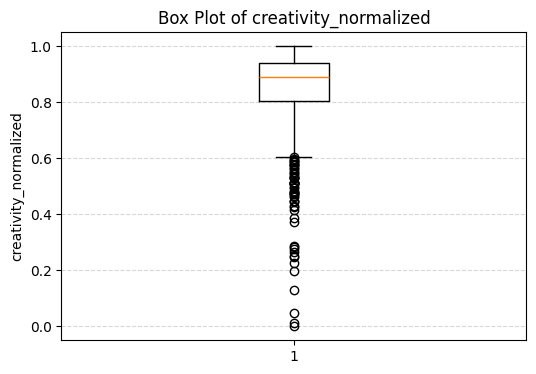

In [51]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [52]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [53]:
np.sum(y)/len(y)

np.float64(0.9723247232472325)

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [55]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [56]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 56.22%
Test AUC: 0.6856240126382307
Test Precision: 0.9915254237288136
Test Recall: 0.5545023696682464
Test F1: 0.7112462006079028


In [57]:
confusion_matrix(y_test, model.predict(X_test))

array([[  5,   1],
       [ 94, 117]])

## Splines 
Splines + Balanced + Normalized (max min)

In [58]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [59]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


In [60]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [61]:
np.sum(y)/len(y)

np.float64(0.9723247232472325)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [63]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [64]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [65]:
model.fit(X_train, y_train)

C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [66]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [67]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 89.86%
Test AUC: 0.4612954186413902
Test Precision: 0.9701492537313433
Test Recall: 0.9241706161137441
Test F1: 0.9466019417475728


In [68]:
confusion_matrix(y_test, y_pred)

array([[  0,   6],
       [ 16, 195]])

## Neural Network

In [69]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [70]:
constant = np.ones(len(surprise_df))

In [71]:
y = [1 if i>=0.5 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [72]:
np.sum(y)/len(y)

np.float64(0.9723247232472325)

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [ ]:
percentile = (creativity_normalized <= 0.85).mean() * 100
percentile

In [74]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [ ]:
ith-row=real class
jth column = predicted

In [75]:
result=[]
best_alpha=None
best_layer=None
best_score=None
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        X_train1, X_val, y_train1, y_val = train_test_split(X_train,y_train, test_size=0.20, random_state=23,stratify=y_train)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train1)
        
        model.fit(X_train1, y_train1, sample_weight = sample_weights)

        
            
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:,1]
        acc = accuracy_score(y_val,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_val, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_val,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_val, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_val, y_pred)

        if best_alpha==None:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
        elif best_score > auc:
            best_alpha = alpha
            best_layer = layer
            best_score = auc
            
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_val, y_pred)})
        #print("Test F1:", f1)



In [ ]:
model = MLPClassifier(solver='lbfgs', alpha=best_alpha,
                    hidden_layer_sizes=best_layer, random_state=1,max_iter=5000)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
model.fit(X_train, y_train, sample_weight = sample_weights)
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob)
print("Test AUC:", auc)
precision = precision_score(y_test,y_pred)
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)
confusion_matrix(y_test, y_pred)

In [76]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",58.064516,0.502370,0.976190,0.582938,0.729970,"[[3, 3], [88, 123]]"
1,0.000001,"(4, 8)",67.741935,0.646919,0.986207,0.677725,0.803371,"[[4, 2], [68, 143]]"
2,0.000001,"(8, 8)",75.115207,0.453397,0.970060,0.767773,0.857143,"[[1, 5], [49, 162]]"
3,0.000001,"(8, 16)",62.672811,0.278041,0.964286,0.639810,0.769231,"[[1, 5], [76, 135]]"
4,0.000001,"(16, 16)",96.313364,0.460506,0.972093,0.990521,0.981221,"[[0, 6], [2, 209]]"
5,0.000001,"(16, 32)",77.880184,0.428120,0.971098,0.796209,0.875000,"[[1, 5], [43, 168]]"
6,0.000003,"(4, 4)",58.064516,0.502370,0.976190,0.582938,0.729970,"[[3, 3], [88, 123]]"
7,0.000003,"(4, 8)",68.202765,0.646130,0.986301,0.682464,0.806723,"[[4, 2], [67, 144]]"
8,0.000003,"(8, 8)",69.124424,0.417062,0.967532,0.706161,0.816438,"[[1, 5], [62, 149]]"
9,0.000003,"(8, 16)",68.663594,0.544234,0.979866,0.691943,0.811111,"[[3, 3], [65, 146]]"


# What if We renormalize the data

In [94]:
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [95]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


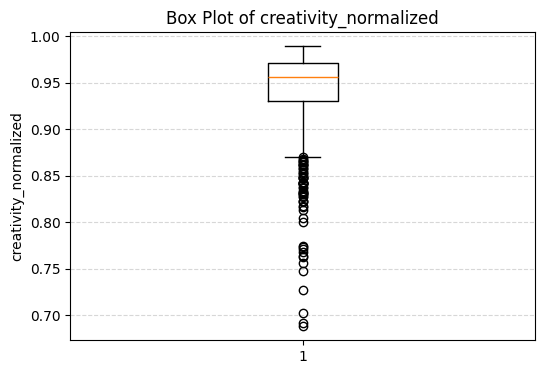

In [96]:
plt.figure(figsize=(6, 4))
plt.boxplot(creative_70, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [97]:
creative = np.array(creativity_normalized, dtype=float)
Q1 = np.percentile(creative, 25)
Q3 = np.percentile(creative, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
creative_outliers =creative[(creative < lower_bound) | (creative > upper_bound)]

In [98]:
np.max(creative_outliers)

np.float64(0.602983932073407)

In [99]:
creative_new = creative[creative>=np.max(creative_outliers)]

In [107]:
creativity_min = np.min(creative_new)
creativity_max =np.max(creative_new)
creativity_normalized = (creative_new - creativity_min)/(creativity_max-creativity_min)

In [112]:
np.min(creativity_normalized)

np.float64(0.0)

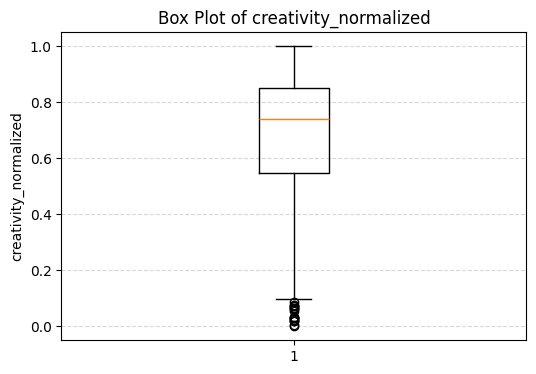

In [110]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [102]:
np.percentile(creativity_normalized, 50)

np.float64(0.7388843635337522)

## Cut off 0.7

### Basic
Balanced + Normalized (max min)

In [135]:
newness_df_new = newness_df[creative>=np.max(creative_outliers)]

In [136]:
newness_df_new.shape

(1027,)

In [137]:
newness_min=np.min(newness_df_new)
newness_max = np.max(newness_df_new)
newness_normalized=(newness_df_new - newness_min)/(newness_max-newness_min)

In [138]:
surprise_df_new = surprise_df[creative>=np.max(creative_outliers)]

In [139]:
surprise_df_new.shape

(1027,)

In [140]:
surprise_min=np.min(surprise_df_new)
surprise_max = np.max(surprise_df_new)
surprise_normalized=(surprise_df_new - surprise_min)/(surprise_max-surprise_min)

In [141]:
value_df_new = value_df[creative>=np.max(creative_outliers)]

In [142]:
value_df_new.shape

(1027,)

In [143]:
value_min=np.min(value_df_new)
value_max = np.max(value_df_new)
value_normalized=(value_df_new - value_min)/(value_max-value_min)

In [144]:
creativity_min = np.min(creative_new)
creativity_max =np.max(creative_new)
creativity_normalized = (creative_new - creativity_min)/(creativity_max-creativity_min)

In [145]:
creativity_normalized.shape

(1027,)

In [146]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.602983932073407. Creativity Max: 1.0.


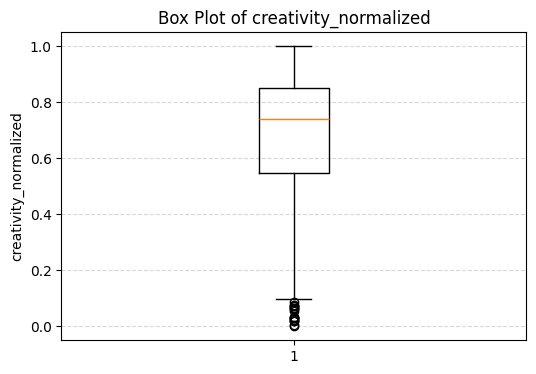

In [147]:
plt.figure(figsize=(6, 4))
plt.boxplot(creativity_normalized, vert=True, showfliers=True)
plt.title("Box Plot of creativity_normalized")
plt.ylabel("creativity_normalized")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [148]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [149]:
np.sum(y)/len(y)

np.float64(0.5589094449853943)

In [150]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [151]:
model = LogisticRegression(max_iter=10000, random_state=0,class_weight="balanced")
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`

In [152]:
acc = accuracy_score(y_test,model.predict(X_test)) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
print("Test AUC:", auc)
precision = precision_score(y_test, model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, model.predict(X_test))
print("Test Recall:", recall)
f1 = f1_score(y_test, model.predict(X_test))
print("Test F1:", f1)

Test Logistic Regression model accuracy: 52.43%
Test AUC: 0.5167701863354037
Test Precision: 0.5779816513761468
Test Recall: 0.5478260869565217
Test F1: 0.5625


In [153]:
confusion_matrix(y_test, model.predict(X_test))

array([[45, 46],
       [52, 63]])

## Splines 
Splines + Balanced + Normalized (max min)

In [58]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [59]:
print(f"Creativity Minimum: {creativity_min}. Creativity Max: {creativity_max}.")

Creativity Minimum: 0.6883131829561187. Creativity Max: 0.9893185386190225.


In [161]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [162]:
np.sum(y)/len(y)

np.float64(0.5589094449853943)

In [163]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [164]:
preprocess = ColumnTransformer([
    ("spline", SplineTransformer(
        degree=3,           # cubic
        n_knots=8,          # tune with CV (e.g., 5–10 common)
        extrapolation="linear",
        include_bias=False  # avoid intercept duplication
    ), [1,2]),
], remainder="drop")

In [165]:
model = make_pipeline(
    preprocess,
    LogisticRegressionCV(cv=5, max_iter=5000, n_jobs=-1,class_weight="balanced")
)

In [166]:
model.fit(X_train, y_train)

C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\MissTiny\anaconda3\envs\Creativity\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('spline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [167]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:,1]

In [168]:
acc = accuracy_score(y_test,y_pred) * 100
print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
auc = roc_auc_score(y_test, y_pred_prob )
print("Test AUC:", auc)
precision = precision_score(y_test,model.predict(X_test))
print("Test Precision:", precision)
recall = recall_score(y_test, y_pred)
print("Test Recall:", recall)
f1 = f1_score(y_test, y_pred)
print("Test F1:", f1)

Test Logistic Regression model accuracy: 53.88%
Test AUC: 0.5523172479694218
Test Precision: 0.6063829787234043
Test Recall: 0.4956521739130435
Test F1: 0.5454545454545454


In [169]:
confusion_matrix(y_test, y_pred)

array([[54, 37],
       [58, 57]])

## Neural Network

In [69]:
newness_min=np.min(newness_df)
newness_max = np.max(newness_df)
newness_normalized=(newness_df - newness_min)/(newness_max-newness_min)
surprise_min=np.min(surprise_df)
surprise_max = np.max(surprise_df)
surprise_normalized=(surprise_df - surprise_min)/(surprise_max-surprise_min)
value_min=np.min(value_df)
value_max = np.max(value_df)
value_normalized=(value_df - value_min)/(value_max-value_min)
creativity_min = np.min(creative_70)
creativity_max =np.max(creative_70)
creativity_normalized = (creative_70 - creativity_min)/(creativity_max-creativity_min)

In [70]:
constant = np.ones(len(surprise_df))

In [170]:
y = [1 if i>=0.7 else 0 for i in creativity_normalized]
X = np.stack((newness_normalized, surprise_normalized,value_normalized), axis=1)

In [171]:
np.sum(y)/len(y)

np.float64(0.5589094449853943)

In [172]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=23,stratify=y)

In [173]:
alphas = [1e-6,3e-6,5e-6,7e-6,9e-6,1e-5]
layers=[(4,4),(4,8),(8,8),(8,16),(16,16),(16,32)]

In [174]:
result=[]
for alpha in alphas:
    for layer in layers:
        model = MLPClassifier(solver='lbfgs', alpha=alpha,
                    hidden_layer_sizes=layer, random_state=1,max_iter=5000)
        sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
        model.fit(X_train, y_train, sample_weight = sample_weights)
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)[:,1]
        acc = accuracy_score(y_test,y_pred) * 100
        #print(f"Test Logistic Regression model accuracy: {acc:.2f}%")
        auc = roc_auc_score(y_test, y_pred_prob)
        #print("Test AUC:", auc)
        precision = precision_score(y_test,y_pred)
        #print("Test Precision:", precision)
        recall = recall_score(y_test, y_pred)
        #print("Test Recall:", recall)
        f1 = f1_score(y_test, y_pred)
        
        result.append({'alpha':alpha,'layer':layer,'acc':acc,'auc':auc,'precision':precision,'recall':recall,'f1':f1,'conf_matrix':confusion_matrix(y_test, y_pred)})
        #print("Test F1:", f1)


In [175]:
df = pd.DataFrame(result)
df

,alpha,layer,acc,auc,precision,recall,f1,conf_matrix
0,0.000001,"(4, 4)",55.339806,0.510893,0.562162,0.904348,0.693333,"[[10, 81], [11, 104]]"
1,0.000001,"(4, 8)",54.854369,0.485093,0.555000,0.965217,0.704762,"[[2, 89], [4, 111]]"
2,0.000001,"(8, 8)",52.427184,0.467941,0.568000,0.617391,0.591667,"[[37, 54], [44, 71]]"
3,0.000001,"(8, 16)",53.398058,0.503297,0.571429,0.660870,0.612903,"[[34, 57], [39, 76]]"
4,0.000001,"(16, 16)",54.368932,0.493072,0.571429,0.730435,0.641221,"[[28, 63], [31, 84]]"
5,0.000001,"(16, 32)",53.883495,0.508743,0.574627,0.669565,0.618474,"[[34, 57], [38, 77]]"
6,0.000003,"(4, 4)",55.825243,0.516340,0.563158,0.930435,0.701639,"[[8, 83], [8, 107]]"
7,0.000003,"(4, 8)",55.339806,0.477496,0.557214,0.973913,0.708861,"[[2, 89], [3, 112]]"
8,0.000003,"(8, 8)",54.368932,0.511037,0.585366,0.626087,0.605042,"[[40, 51], [43, 72]]"
9,0.000003,"(8, 16)",52.912621,0.502532,0.569231,0.643478,0.604082,"[[35, 56], [41, 74]]"
